In [1]:
%cd ../

/nas/zhangtianning.di/projects/unique_data_build


In [2]:
from uparxive.lougat.markdown_pdf_align import *

In [3]:
html_path = "/nvme/zhangtianning.di/sharefold/whole_arxiv_all_files/archive_tex.colorful.nobbl/1907/1907.07639/temp/1907.07639.colorful.html"

In [6]:
# html = read_and_standardlize_html(html_path)
# with open('test.html','w') as f:f.write(html.prettify())
# mmd,fig = soup2mdtext(html)
# mmd = re.sub(r"\\definecolor(\s*\[.*?\])?\s*\{[^}]*\}\s*\{\s*rgb\s*}\s*\{[^}]*\}", "", mmd)
# with open('test.mmd','w') as f:f.write(mmd)

In [6]:
html = read_and_standardlize_html(html_path)
#mmd,fig = soup2mdtext(html)
doc = parse_latexml(html)

In [7]:
from uparxive.lougat.nougat_parser_with_color import *

In [8]:
doc = Document()
parse_latexml_children(html, doc)

In [ ]:
(mmd,
mmd_color_dct,
cap_color_dct,
fig_color_dct,
fig_captions_list,
color_figid_map,block_equation_color_map) = get_markdown_text_with_colored(html_path)

In [5]:
with open('test.mmd','w') as f:
    f.write(mmd)

In [6]:
from PIL import Image, ImageDraw
pdf_file_path  = html_path[:-5] + '.pdf'
now_table_figure_masked_pdf = pdf_file_path
pdf_file_path = pdf_file_path#.replace('.colorful.pdf','.colorful_all_colored.pdf')
pdf      = fitz.open(pdf_file_path)
pdf0     = fitz.open(now_table_figure_masked_pdf)
png_dir  = os.path.join(os.path.dirname(os.path.dirname(pdf_file_path)),'boxed_pdf_image')
os.makedirs(png_dir,exist_ok=True)

In [8]:
recommand_start = 0
for page_idx in range(0,len(pdf)):
    page = pdf[page_idx]
    page0=pdf0[page_idx]
    clean_png_path = os.path.join(png_dir, 'clean',f"page_{page_idx}.png")
    os.makedirs(os.path.dirname(clean_png_path),exist_ok=True)
    with open(clean_png_path, "wb") as f:
        f.write(page0.get_pixmap(dpi=300).pil_tobytes(format="PNG"))      
    current_mmd_color_dct = mmd_color_dct
    pretext_and_prompts,true_match,recommand_start = deal_with_single_page(page,current_mmd_color_dct,block_equation_color_map,cap_color_dct,fig_color_dct,color_figid_map,fig_captions_list,recommand_start=recommand_start)
    print(f"recommand_start={recommand_start}")
    if pretext_and_prompts == None:
        print(f""" ============ fail to processing page {page_idx} ======================= """)
    else:
        _,_,page_w,page_h = page.rect
        normed_pretext_and_prompts = []
        for text,_,_,_, bbox in pretext_and_prompts:
            if isinstance(bbox,tuple) and len(bbox)==4:
                bbox  = norm_box(bbox,page_h,page_w)
            normed_pretext_and_prompts.append([text, bbox])
        print(f""" ============= for page {page_idx}, we get {len(normed_pretext_and_prompts)} box =================== """)

recommand_start=576
 ============= for page 0, we get 562 box =================== 
recommand_start=1055
 ============= for page 1, we get 479 box =================== 
recommand_start=1500
 ============= for page 2, we get 446 box =================== 
recommand_start=1925
 ============= for page 3, we get 422 box =================== 
recommand_start=2112
 ============= for page 4, we get 342 box =================== 
recommand_start=2508
 ============= for page 5, we get 447 box =================== 
recommand_start=2958
 ============= for page 6, we get 724 box =================== 
recommand_start=3414
 ============= for page 7, we get 452 box =================== 
recommand_start=3656
 ============= for page 8, we get 816 box =================== 
recommand_start=4153
 ============= for page 9, we get 496 box =================== 
recommand_start=4593
 ============= for page 10, we get 1217 box =================== 
recommand_start=4884
 ============= for page 11, we get 339 box ===========

ValueError: max() arg is an empty sequence

In [8]:
_,_,page_w,page_h = page.rect
normed_pretext_and_prompts = []
for markdown, pdf_text, status, text_type, bbox in pretext_and_prompts:
    if bbox and isinstance(bbox,tuple) and len(bbox)==4:
        bbox  = norm_box(bbox,page_h,page_w)
    normed_pretext_and_prompts.append([markdown, pdf_text, status, text_type, bbox])

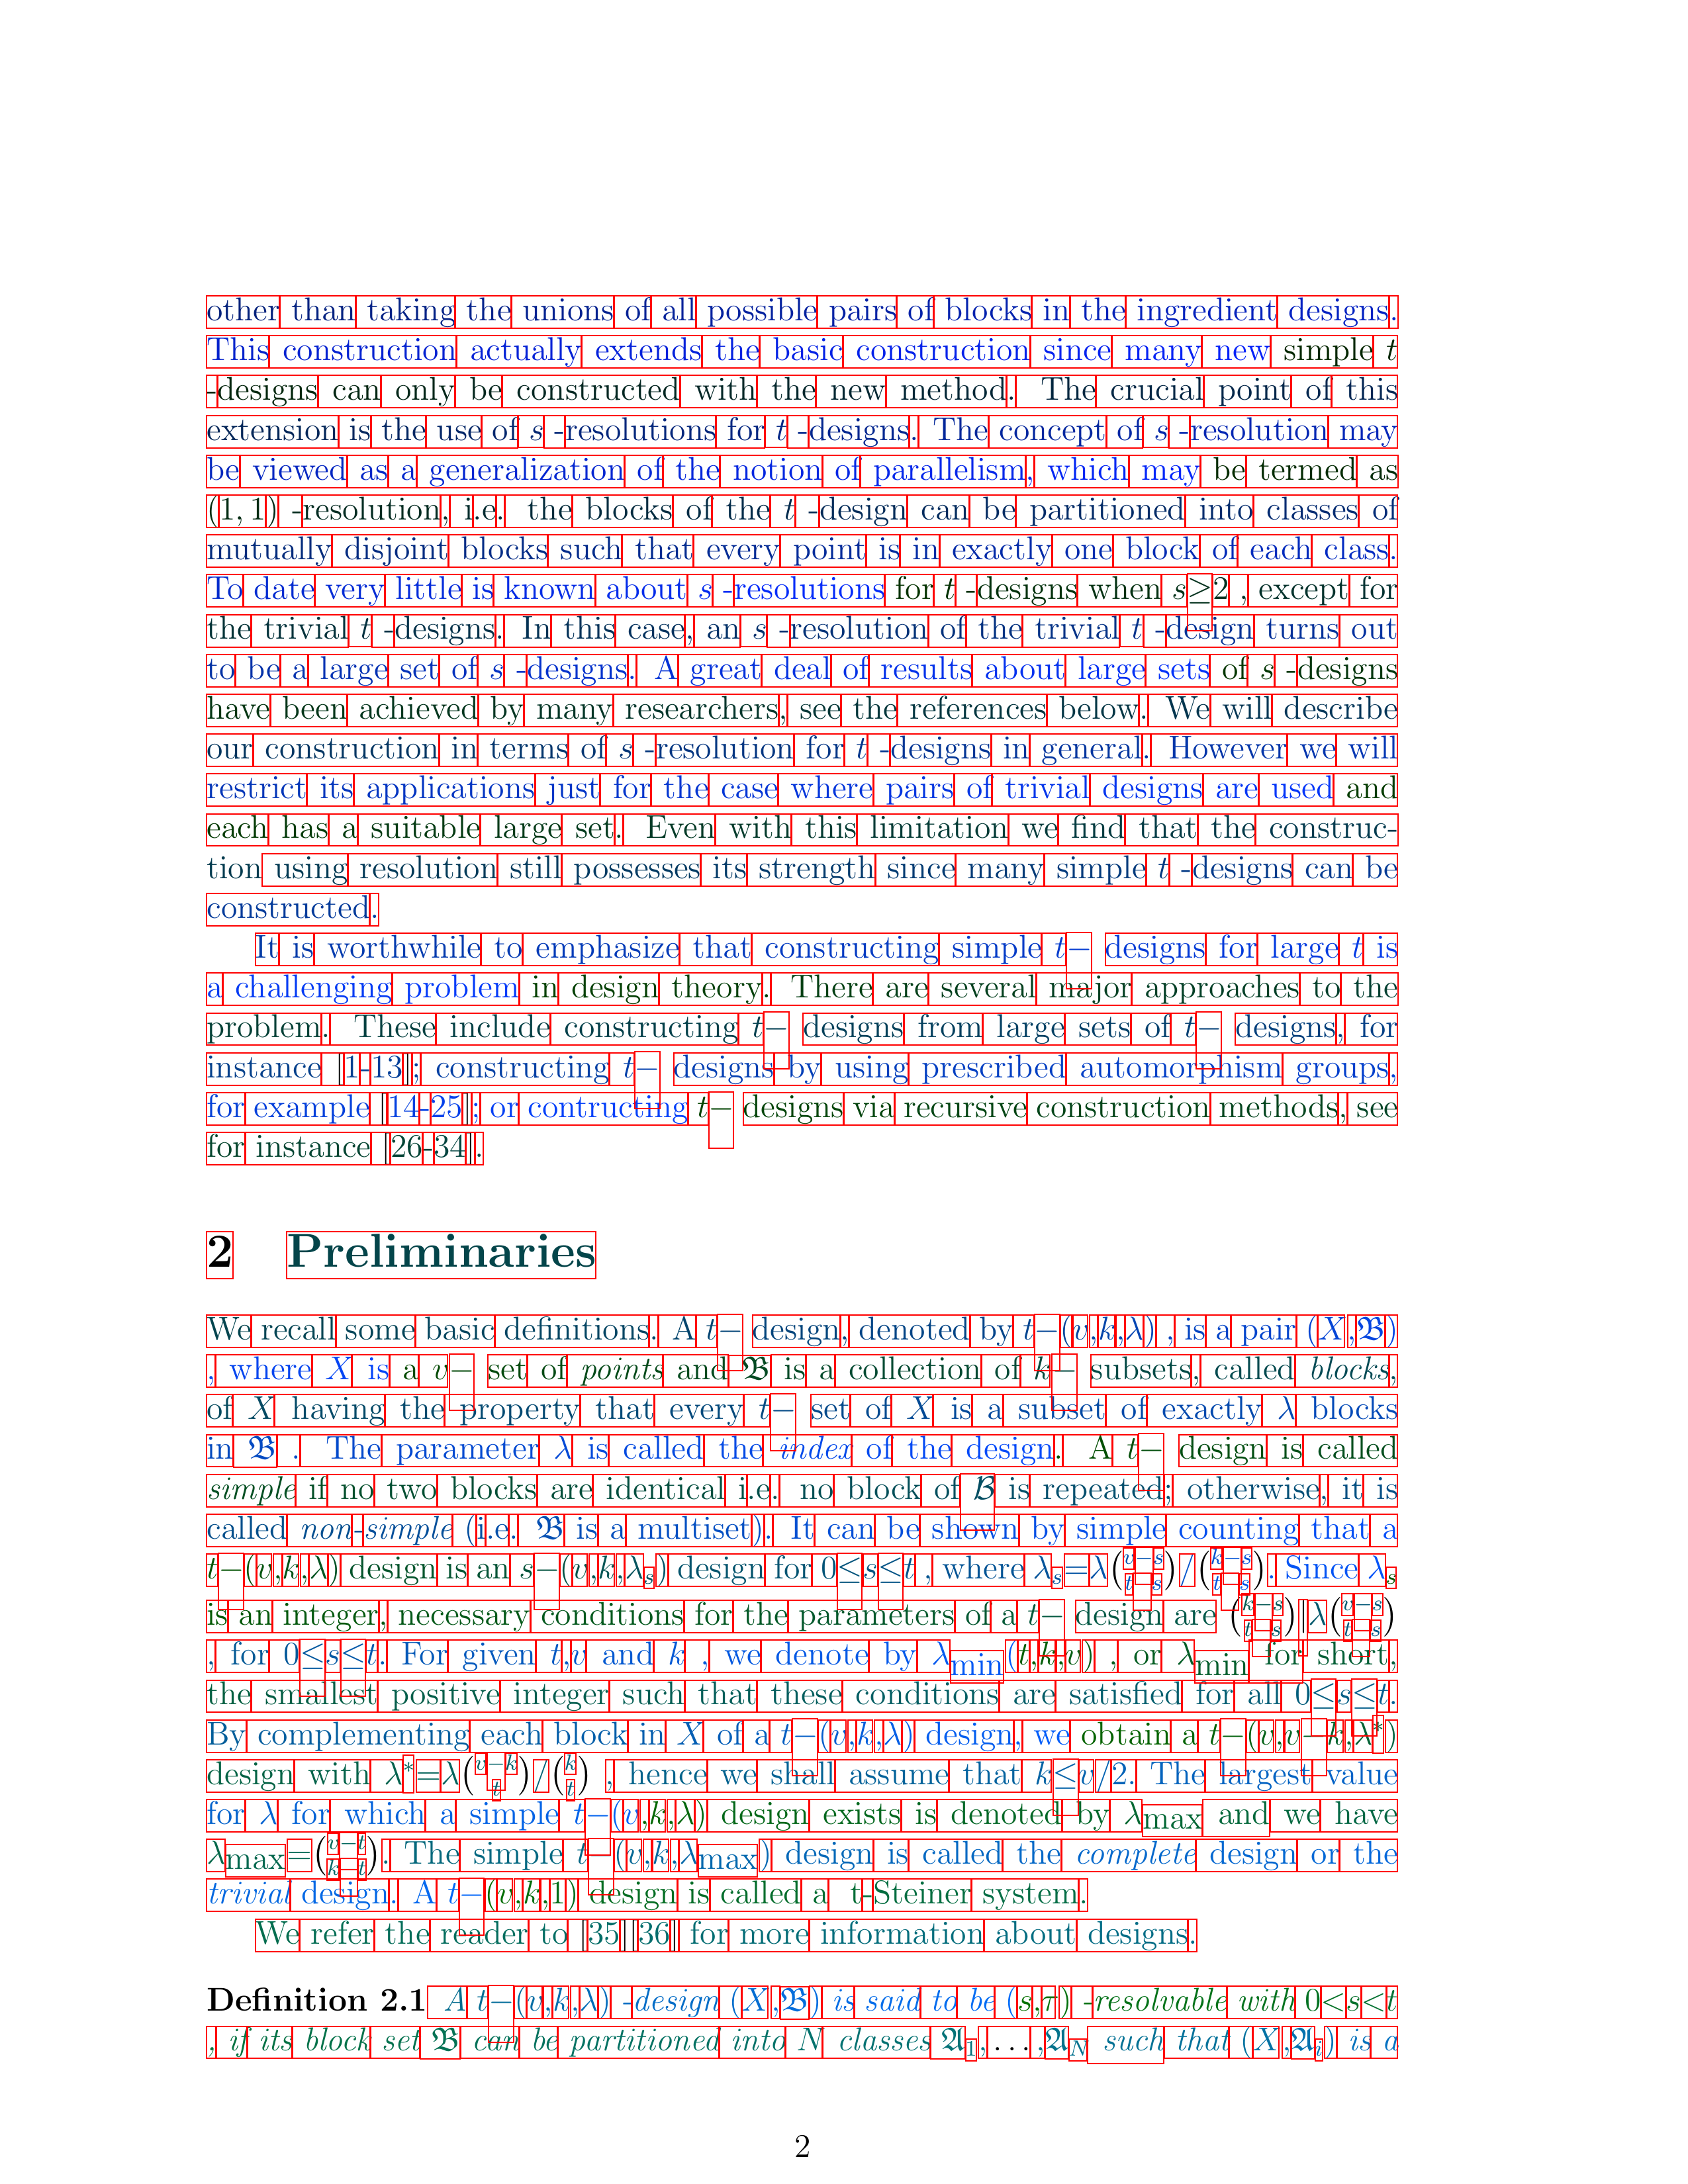

In [9]:
img = Image.open(clean_png_path)

for markdown, pdf_text, status, text_type, box in normed_pretext_and_prompts:
    if box is None:continue

    #if len(text_and_box)!=2:logging.debug(text_and_box)
    #text, box = text_and_box
    #if box is None:logging.debug(text_and_box)
    if len(box[0])!=2 or len(box[1])!=2: continue
    bbox = box
    width, height = img.size

    # Convert bbox from normalized to pixel coordinates
    pixel_bbox = [
        bbox[0][0] * width,  # xmin
        bbox[0][1] * height, # ymin
        bbox[1][0] * width,  # xmax
        bbox[1][1] * height  # ymax
    ]

    # Create a draw object
    draw = ImageDraw.Draw(img)

    # Draw the rectangle
    draw.rectangle(pixel_bbox, outline='red', width=2)

boxed_image = os.path.join(png_dir, 'boxed',f"boxed_page_{page_idx}.png")
#os.makedirs(os.path.dirname(boxed_image),exist_ok=True)
#img.save(boxed_image)
img

In [54]:
content = ""
for text, _, _, text_type, bbox in pretext_and_prompts:
    end = "" if text_type =="<inline_math>" else " "
    content += text + end

In [55]:
print(content)

Radiative decays of charged leptons as constraints of unitarity polygons

 for active - sterile neutrino mixing and CP violation

 Zhi - zhong Xing 1,2 and Di Zhang Institute of High Energy Physics and School of Physical Sciences ,

 University of Chinese Academy of Sciences , Beijing 100049, China

 Center of High Energy Physics , Peking University , Beijing 100871, China

 ###### Abstract

 We calculate the rates of radiative \(\beta^{-}\to\alpha^{-}+\gamma \)decays for \((\alpha,\beta)=(e,\mu) \), \((e,\tau) \)and \((\mu,\tau) \)by taking the unitary gauge in the \((3+n) \)active - sterile neutrino mixing scheme , and make it clear that constraints on the unitarity of the \(3\times 3 \)Pontecorvo - Maki - Nakagawa - Sakata ( PMNS ) matrix \(U \)extracted from \(\beta^{-}\to \alpha^{-}+\gamma \)decays in the minimal unitarity violation scheme differ from those obtained in the canonical seesaw mechanism with \(n \)heavy Majorana neutrinos by a factor \(5/3 \). In such a natural seesaw

In [171]:
def rgb_to_hex(r, g, b):
    return f'#{r:02X}{g:02X}{b:02X}'
rgb_to_hex(50, 5, 175)

'#3205AF'

In [172]:
hex_to_rgb('0AFAA5')

(10, 250, 165)

# debug

In [56]:
sequence2boxed,caption_matched_in_this_page,figid_from_figure, figid_from_caption, pdf_draw_color_bbox_map,color_to_position = get_pdf_text_with_colored(page,block_equation_color_map,cap_color_dct,fig_color_dct,color_figid_map,fig_captions_list)

In [57]:
pretext_and_prompts,true_match,recommand_start  = sequence_sequence_alignment(current_mmd_color_dct,sequence2boxed)

In [38]:

caption_start_position = 0
pretext_and_prompts[-1][0]+='\n\n'
caption2boxed=[(c,t,b) for c,(t,b) in caption_matched_in_this_page.items()]
for figid in figid_from_figure:
    caption2boxed_now = caption2boxed[caption_start_position:]
    fig_cap = fig_captions_list[figid]
    fig = fig_cap['figure']
    cap = fig_cap['caption']
    for c, v in fig.items():
        if v[0] == "FOOTNOTE":
            pretext_and_prompts.append((f"<footnote>{v}</footnote>\n","",'invisable','mask',None))
        else:
            pretext_and_prompts.append((f"<fig>{v}</fig>\n","",'invisable','mask', pdf_draw_color_bbox_map[c]))
    if len(cap)>0:
        pretext_and_prompts.append((f"<cap>","",'invisable','mask',None))
        pretext_and_prompts2,true_match_caption, _ = sequence_sequence_alignment(cap,caption2boxed_now, align_side='right')
        caption_start_position = 0 #true_match_caption[-1][-1]
        pretext_and_prompts.extend(pretext_and_prompts2)
        pretext_and_prompts.append((f"</cap>","",'invisable','mask',None))

In [58]:
recommand_start=0
sequence1o = [(color, text, dtype) for color, (text, dtype) in current_mmd_color_dct.items()]

color_indexes_map = {color:i for i,(color, text, dtype) in enumerate(sequence1o) if color!=(0,0,0) and is_meaningful_markdonw_color(color)}
sequence_pdf = sequence2boxed
color_index_in_pdf = [color_indexes_map[color] for color,_,_ in sequence_pdf if color !=(0,0,0) and color in color_indexes_map] ### some color may appear in caption, then pass
mmd_sequence_start  = max(max(0,min(color_index_in_pdf)-1),recommand_start)
while mmd_sequence_start>0 and "math" in sequence1o[mmd_sequence_start][-1]:
    mmd_sequence_start-=1
mmd_sequence_end    = max(color_index_in_pdf[1:])+1
while "math" in sequence1o[mmd_sequence_end][-1]:
    mmd_sequence_end+=1
sequence_mmd = [(color, text, dtype) for color, text, dtype in sequence1o[mmd_sequence_start:mmd_sequence_end]]
sequence1=sequence_mmd
sequence2=sequence_pdf

pair = rough_split_by_color_pair(sequence2, sequence1)
fail_to_match = False

In [59]:
sequence1

[((230, 130, 120), 'Radiative', '<text>'),
 ((230, 130, 125), 'decays', '<text>'),
 ((230, 130, 130), 'of', '<text>'),
 ((230, 130, 135), 'charged', '<text>'),
 ((230, 130, 140), 'leptons', '<text>'),
 ((230, 130, 145), 'as', '<text>'),
 ((230, 130, 150), 'constraints', '<text>'),
 ((230, 130, 155), 'of', '<text>'),
 ((230, 130, 160), 'unitarity', '<text>'),
 ((230, 130, 165), 'polygons\n\n', '<text>'),
 ((230, 130, 170), 'for', '<text>'),
 ((230, 130, 175), 'active', '<text>'),
 ((230, 130, 180), '-', '<text>'),
 ((230, 130, 185), 'sterile', '<text>'),
 ((230, 130, 190), 'neutrino', '<text>'),
 ((230, 130, 195), 'mixing', '<text>'),
 ((230, 130, 200), 'and', '<text>'),
 ((230, 130, 205), 'CP', '<text>'),
 ((230, 130, 210), 'violation\n\n', '<text>'),
 ((230, 130, 215), 'Zhi', '<text>'),
 ((230, 130, 220), '-', '<text>'),
 ((230, 130, 225), 'zhong', '<text>'),
 ((230, 130, 230), 'Xing', '<text>'),
 ((230, 130, 230.1), '1,2', '<text>'),
 ((230, 130, 240), 'and', '<text>'),
 ((230, 130, 

In [64]:
while len(pair)>0 and pair[-1][0] == 'need':
    pair.pop(-1)  ### this while totally remove the last sequence match ability but make more accuracte when color is applied properly
if len(pair)==0:
    fail_to_match = True

In [61]:
for tag, i1,i2,j1,j2 in pair:
    print('{:7}   seq1[{}:{}] --> {}'.format(tag, i1, i2, [t[1] for t in sequence1[i1:i2]]))
    print('          seq2[{}:{}] --> {}\n'.format(j1, j2, [t[1] for t in sequence2[j1:j2]]))

aligned   seq1[0:1] --> ['Radiative']
          seq2[0:1] --> ['Radiative']

aligned   seq1[1:2] --> ['decays']
          seq2[1:2] --> ['decays']

aligned   seq1[2:3] --> ['of']
          seq2[2:3] --> ['of']

aligned   seq1[3:4] --> ['charged']
          seq2[3:4] --> ['charged']

aligned   seq1[4:5] --> ['leptons']
          seq2[4:5] --> ['leptons']

aligned   seq1[5:6] --> ['as']
          seq2[5:6] --> ['as']

aligned   seq1[6:7] --> ['constraints']
          seq2[6:7] --> ['constraints']

aligned   seq1[7:8] --> ['of']
          seq2[7:8] --> ['of']

aligned   seq1[8:9] --> ['unitarity']
          seq2[8:9] --> ['unitarity']

aligned   seq1[9:10] --> ['polygons\n\n']
          seq2[9:10] --> ['polygons']

aligned   seq1[10:11] --> ['for']
          seq2[10:11] --> ['for']

aligned   seq1[11:12] --> ['active']
          seq2[11:12] --> ['active']

aligned   seq1[12:13] --> ['-']
          seq2[12:13] --> ['-']

aligned   seq1[13:14] --> ['sterile']
          seq2[13:14] --> ['ste

In [65]:
sequence1_text = []
for c, text, _type in sequence1:

    text = text.strip()
    if _type == '<inline_math>':
        text = regex.sub(fontpattern, lambda m:m[1][1:-1],text)
    sequence1_text.append(text) 
sequence2_text = [t[1].strip() for t in sequence2]

true_match = []
for tag, i1,i2,j1,j2 in pair:
    if tag == 'need':

        seq1 = sequence1_text[i1:i2]
        seq2 = sequence2_text[j1:j2]
        if len(seq2) == 0 and len(seq1)>0 and all([t[-1]== '<inline_math>' for t in sequence1[i1:i2]]):
            true_match.append([tag,i1,i2,j1,j2])
            continue
        if len(seq1) == 0 and len(seq2)>0:
            true_match.append([tag,i1,i2,j1,j2])
            continue
        if len(seq1) == 0 and len(seq2) == 0:
            continue

        for tag, i1_now, i2_now, j1_now, j2_now in get_real_match(seq1, seq2):
            true_match.append([tag,i1+i1_now, i1+i2_now,j1+j1_now, j1+j2_now])
    else:
        true_match.append([tag,i1, i2,j1, j2])

In [67]:
seq1 = sequence1_text[531:532]
seq2 = sequence2_text[463:464]

In [69]:
seq1, seq2

(['}|'], ['|'])

In [62]:
true_match = reorder_pair_match(true_match,sequence1,sequence2)

In [66]:
for tag, i1, i2, j1, j2 in true_match:
    print('{:7}   seq1[{}:{}] --> {}'.format(tag, i1, i2, sequence1[i1:i2]))
    print('          seq2[{}:{}] --> {}\n'.format(j1, j2, sequence2[j1:j2]))    

aligned   seq1[0:1] --> [((230, 130, 120), 'Radiative', '<text>')]
          seq2[0:1] --> [((230, 130, 120), 'Radiative', (51.196998596191406, 47.62334442138672, 118.59546661376953, 61.983890533447266))]

aligned   seq1[1:2] --> [((230, 130, 125), 'decays', '<text>')]
          seq2[1:2] --> [((230, 130, 125), 'decays', (118.59546661376953, 47.62334442138672, 169.75399780273438, 61.983890533447266))]

aligned   seq1[2:3] --> [((230, 130, 130), 'of', '<text>')]
          seq2[2:3] --> [((230, 130, 130), 'of', (169.75399780273438, 47.62334442138672, 188.1458282470703, 61.983890533447266))]

aligned   seq1[3:4] --> [((230, 130, 135), 'charged', '<text>')]
          seq2[3:4] --> [((230, 130, 135), 'charged', (188.1458282470703, 47.62334442138672, 248.06988525390625, 61.983890533447266))]

aligned   seq1[4:5] --> [((230, 130, 140), 'leptons', '<text>')]
          seq2[4:5] --> [((230, 130, 140), 'leptons', (248.06988525390625, 47.62334442138672, 303.94830322265625, 61.983890533447266))]



In [107]:
sequence_mmd[true_match[-1][2]-1][2]

'<block_math>'

In [109]:
align_side = 'left'
if align_side == 'left':
    while true_match[-1][0] == 'delete' and 'math' not in sequence_mmd[true_match[-1][2]-1][2]:
        true_match.pop(-1)
else:
    while true_match[-1][0] != 'aligned' and 'math' not in sequence_mmd[true_match[-1][2]-1][2]:
        true_match.pop(-1)


############## final match align ##################
now_we_add_postion_in_mmd = mmd_sequence_start + true_match[-1][1]
pretext_and_prompts = generate_final_match_table(true_match, sequence1, sequence2, verbose_level=1)

In [18]:
sequence1o = [(color, text, dtype) for color, (text, dtype) in current_mmd_color_dct.items()]

color_indexes_map = {color:i for i,(color, text, dtype) in enumerate(sequence1o) if color!=(0,0,0) and is_meaningful_markdonw_color(color)}
sequence_pdf = sequence2boxed
color_index_in_pdf = [color_indexes_map[color] for color,_,_ in sequence_pdf if color !=(0,0,0) and color in color_indexes_map] ### some color may appear in caption, then pass
sequence_mmd = [(color, text, dtype) for color, text, dtype in sequence1o[max(0,min(color_index_in_pdf)-1):max(color_index_in_pdf)+1]]
sequence1=sequence_mmd
sequence2=sequence_pdf

In [12]:
import latex2mathml.commands as commands

In [19]:
pair = rough_split_by_color_pair(sequence2, sequence1)
fail_to_match = False


while len(pair)>0 and pair[-1][0] == 'need':
    pair.pop(-1)  ### this while totally remove the last sequence match ability but make more accuracte when color is applied properly
if len(pair)==0:
    fail_to_match = True

In [20]:
for tag, i1, i2, j1, j2 in pair:
    print('{:7}   seq1[{}:{}] --> {}'.format(tag, i1, i2, sequence1[i1:i2]))
    print('          seq2[{}:{}] --> {}\n'.format(j1, j2, sequence2[j1:j2]))    

need      seq1[0:1] --> [((0, 0, 0.2), '1:', '<text>')]
          seq2[0:0] --> []

aligned   seq1[1:2] --> [((10, 165, 155), 'Containment', '<text>')]
          seq2[0:1] --> [((10, 165, 155), 'Containment', (240.5019073486328, 196.99703979492188, 301.393310546875, 206.9596405029297))]

aligned   seq1[2:3] --> [((10, 165, 160), 'of', '<text>')]
          seq2[1:2] --> [((10, 165, 160), 'of', (301.393310546875, 196.99703979492188, 312.74072265625, 206.9596405029297))]

aligned   seq1[3:4] --> [((10, 165, 165), 'language', '<text>')]
          seq2[2:3] --> [((10, 165, 165), 'language', (312.74072265625, 196.99703979492188, 354.2747802734375, 206.9596405029297))]

aligned   seq1[4:5] --> [((10, 165, 170), 'families', '<text>')]
          seq2[3:4] --> [((10, 165, 170), 'families', (354.2747802734375, 196.99703979492188, 390.5784606933594, 206.9596405029297))]



In [21]:
order_for_sequence_1 = {}
for tag, i1, i2, j1, j2 in pair:
    if i1 not in order_for_sequence_1:
        order_for_sequence_1[i1] = [(i2, j1, j2, tag)]
    else:
        if i2 - i1 > 0:
            old_i2, old_j1, old_j2, old_tag = order_for_sequence_1[i1][-1]
            old_i1 = i1
            if (j2 - j1) ==0 or (old_j2 - old_j1) ==0 or (old_i2-old_i1)==0:
                # seem add a delete task: lets append and continue
                order_for_sequence_1[i1].append((i2, j1, j2, tag))
            else:
                print("below case since has multiple align")
                print('new:')
                print('   {:7}   seq1[{}:{}] --> {}'.format(tag, i1, i2, sequence1[i1:i2]))
                print('             seq2[{}:{}] --> {}\n'.format(j1, j2, sequence2[j1:j2])) 
                print('old:')
                print('   {:7}   seq1[{}:{}] --> {}'.format(tag, old_i1, old_i2, sequence1[old_i1:old_i2]))
                print('             seq2[{}:{}] --> {}\n'.format(old_j1, old_j2, sequence2[old_j1:old_j2])) 
        else:
            order_for_sequence_1[i1].append((i2, j1, j2, tag))

In [29]:
order_for_sequence_1

{0: [(1, 0, 0, 'need')],
 1: [(2, 0, 1, 'aligned')],
 2: [(3, 1, 2, 'aligned')],
 3: [(4, 2, 3, 'aligned')],
 4: [(5, 3, 4, 'aligned')]}

In [35]:
i1 = i2 = j1 = j2 = 0
new_pair = []
while i2 < len(sequence1) and j2 < len(sequence2):
    if i1 not in order_for_sequence_1:
        i2 = i1 + 1
        new_pair.append(['delete', i1, i2, j2,j2])
        j2+=1
        i1 = i2
        continue
    for i2, j1, j2, tag in order_for_sequence_1[i1]:
        new_pair.append([tag, i1, i2, j1,j2])
    i1 = i2

In [36]:
for tag, i1, i2, j1, j2 in new_pair:
    print('{:7}   seq1[{}:{}] --> {}'.format(tag, i1, i2, sequence1[i1:i2]))
    print('          seq2[{}:{}] --> {}\n'.format(j1, j2, sequence2[j1:j2]))    

need      seq1[0:1] --> [((0, 0, 0.2), '1:', '<text>')]
          seq2[0:0] --> []

aligned   seq1[1:2] --> [((10, 165, 155), 'Containment', '<text>')]
          seq2[0:1] --> [((10, 165, 155), 'Containment', (240.5019073486328, 196.99703979492188, 301.393310546875, 206.9596405029297))]

aligned   seq1[2:3] --> [((10, 165, 160), 'of', '<text>')]
          seq2[1:2] --> [((10, 165, 160), 'of', (301.393310546875, 196.99703979492188, 312.74072265625, 206.9596405029297))]

aligned   seq1[3:4] --> [((10, 165, 165), 'language', '<text>')]
          seq2[2:3] --> [((10, 165, 165), 'language', (312.74072265625, 196.99703979492188, 354.2747802734375, 206.9596405029297))]

aligned   seq1[4:5] --> [((10, 165, 170), 'families', '<text>')]
          seq2[3:4] --> [((10, 165, 170), 'families', (354.2747802734375, 196.99703979492188, 390.5784606933594, 206.9596405029297))]



In [33]:
pair = new_pair

In [34]:
sequence1_text = []
for c, text, _type in sequence1:

    text = text.strip()
    if _type == '<inline_math>':
        text = regex.sub(fontpattern, lambda m:m[1][1:-1],text)
    sequence1_text.append(text) 
sequence2_text = [t[1].strip() for t in sequence2]

true_match = []
for tag, i1,i2,j1,j2 in pair:
    if tag == 'need':
        
        seq1 = sequence1_text[i1:i2]
        seq2 = sequence2_text[j1:j2]
        if len(seq2) == 0 and len(seq1)>0 and all([t[-1]== '<inline_math>' for t in sequence1[i1:i2]]):
            true_match.append([tag,i1,i2,j1,j2])
            continue
        if len(seq1) == 0 and len(seq2)>0:
            true_match.append([tag,i1,i2,j1,j2])
            continue
        if len(seq1) == 0 and len(seq2) == 0:
            continue
            
        for tag, i1_now, i2_now, j1_now, j2_now in get_real_match(seq1, seq2):
            true_match.append([tag,i1+i1_now, i1+i2_now,j1+j1_now, j1+j2_now])
    else:
        true_match.append([tag,i1, i2,j1, j2])

In [35]:
for tag, i1, i2, j1, j2 in true_match:
    print('{:7}   seq1[{}:{}] --> {}'.format(tag, i1, i2, sequence1[i1:i2]))
    print('          seq2[{}:{}] --> {}\n'.format(j1, j2, sequence2[j1:j2]))    

delete    seq1[0:1] --> [((10, 105, 155), 'then', '<text>')]
          seq2[0:0] --> []

aligned   seq1[1:2] --> [((10, 105, 160), 'there', '<text>')]
          seq2[0:1] --> [((10, 105, 160), 'there', (68.4010009765625, 228.82205200195312, 90.01146697998047, 238.78465270996094))]

aligned   seq1[2:3] --> [((10, 105, 165), 'exist', '<text>')]
          seq2[1:2] --> [((10, 105, 165), 'exist', (90.01146697998047, 228.82205200195312, 113.52487182617188, 238.78465270996094))]

aligned   seq1[3:4] --> [((10, 105, 170), 'two', '<text>')]
          seq2[2:3] --> [((10, 105, 170), 'two', (113.52487182617188, 228.82205200195312, 132.3416748046875, 238.78465270996094))]

aligned   seq1[4:5] --> [((10, 105, 175), 'distinct', '<text>')]
          seq2[3:4] --> [((10, 105, 175), 'distinct', (132.3416748046875, 228.82205200195312, 168.49746704101562, 238.78465270996094))]

aligned   seq1[5:6] --> [((10, 105, 180), 'indices', '<text>')]
          seq2[4:5] --> [((10, 105, 180), 'indices', (168.49746

In [193]:
def generate_final_match_table(true_match, sequence_mmd, sequence2boxed, verbose_level=1):
    """
    Get output type [ markdown_text, pdf_text, status, text_type, text_bbox]
    """
    pretext_and_prompts = []
    color_table_seq_pdf = {c: i for i, (c,_,_) in enumerate(sequence2boxed) if c != (0,0,0) and is_meaningful_markdonw_color(c)}
    for tag, i1, i2, j1, j2 in true_match:

        markdown_parts = sequence1o[i1:i2]
        pdf_color_box  = sequence2boxed[j1:j2]
        pdf_text       = " ".join([t[1] for t in pdf_color_box]) ### <--- pdf text
        
        if len(markdown_parts)==0: ### <--- then it be an insect case
            if len(pdf_text.strip())==0:continue
            if not all([sum(t[0])==0 for t in pdf_color_box]):

                logging.debug(f"({tag}, {i1}, {i2}, {j1}, {j2})This an empty markdown text but not empty pdf color box, throw it: the pdf box data is:")
                for data in pdf_color_box:
                    logging.debug(f"color={data[0]}, text= {data[1]}")
                logging.debug("=========================")
            else:
                logging.info(f"safe throw: markdown_text={markdown_parts} pdf_text={pdf_text}")
            continue
        
        if len(pdf_color_box) == 0: ### <--- then it be an delete case
            for c, text, _type in markdown_parts:
                if len(text.strip())==0:continue
                if invisable_symbol(text,_type):
                    pretext_and_prompts.append([text,"", "invisable", _type ,(-1,-1,-1)])
                else:
                    if verbose_level>0:
                        if is_meaningful_markdonw_color(c):
                            logging.debug(f"[Important] why you throw a meaningful markdown color={c} text={text}")
                        else:
                            logging.info(f"it seem you have to throw a text to match. The text={text} with color={c}")
            continue
        if len(markdown_parts)>1:
            raise NotImplementedError(f"seem has problem for this mardown text: {markdown_parts} ")
            
            
        (color,markdown_text, markdown_type) =  markdown_parts[0]

        if tag in ['equal','aligned']:
            merged_bbox   = merge_bboxes([t[2] for t in pdf_color_box])
            if merged_bbox is None:merged_bbox = pdf_color_box[0][2]
            char_markdown = re.sub(r'[ -]+', '', markdown_text).lower()
            char_pdf = re.sub(r'[ -]+', '', "".join(pdf_text)).lower()
            if  (char_markdown != char_pdf and 
                not  char_markdown.startswith(char_pdf) and 
                not  char_pdf.startswith(char_markdown) and
                not  char_markdown.endswith(char_pdf) and
                not  char_pdf.endswith(char_markdown) and
                not  invisable_symbol(markdown_text,markdown_type)
                ):

                if any([isinstance(c,float) for c in color]) :
                    pretext_and_prompts.append([markdown_text, pdf_text, 'throw', markdown_type, (-1, -1, -1)])
                    print(f"bad match!!! throw {markdown_type}:{markdown_text.strip()}<=>{pdf_text.strip()} char level is {char_markdown}<=>{char_pdf} {[int(l) for l in merged_bbox]}")
                else:
                    pretext_and_prompts.append([markdown_text, pdf_text, 'invisable', markdown_type, (-1, -1, -1)])
                    print(f"bad match!!! but {markdown_text.strip()} is a invisable sign, skip")
                continue
            if merged_bbox is None:
                ### is may due to the Line breaks such as 
                ###  xxxxxxxxxx out-
                ###  side xxxxxxxxxx
                ###  xxxxxxxxxxxxxxx
                ### for those case, lets divide the markdown_text
                if char_markdown != char_pdf:
                    logging.info(f"mismatch?? [{markdown_text}] <=> [{pdf_text}]")
                for color_box in pdf_color_box:
                    markdown_text = pdf_text = color_box[1]
                    merged_bbox   = color_box[2]
                    pretext_and_prompts.append([markdown_text, pdf_text, 'match' ,markdown_type,merged_bbox])
                    logging.info(f"{tag:7s} {markdown_text.strip():20s} {pdf_text.strip():20s} {[int(l) for l in merged_bbox]}")

            else:
                pretext_and_prompts.append([markdown_text, pdf_text, 'match' ,markdown_type,merged_bbox])
                logging.info(f"{tag:7s} {markdown_text.strip():20s} {pdf_text.strip():20s} {[int(l) for l in merged_bbox]}")

        elif tag == 'delete':
            if is_this_part_is_invisable_symbol_in_markdown(markdown_text):
                logging.info("this is the invisable markdown text", markdown_text.strip(),pdf_text.strip() )
                pretext_and_prompts.append([markdown_text, pdf_text, "invisable" ,markdown_type, (-1,-1,-1)])
            elif any([isinstance(c,float) for c in color]):

                if all([t['color']==0 for t in pdf_color_box]):
                    ### this mean there is symbol in markdown is not get colored by pdf engine like µ
                    ### lets put it back to last markdown slot
                    ##### since we pre caption already, this still should not appear here 
                    raise NotImplementedError(f"why you throw a symbol but no color source: markdown_text={markdown_text.strip()} pdf_text={pdf_text.strip()}")
                    if pretext_and_prompts and pretext_and_prompts[-1][2]!='throw':
                        pretext_and_prompts[-1][0]+=' '+markdown_text
                    logging.info("put the symbol to last markdone slot", markdown_text.strip(),pdf_text.strip() )
                else:
                    logging.info(f"safe throw as it is a black symbol but no markdown source: markdown_text={markdown_text.strip()} pdf_text={pdf_text.strip()}")
            elif color in color_table_seq_pdf:
                target_j = color_table_seq_pdf[color]
                pdf_text = sequence2boxed[target_j]['text']
                merged_bbox = sequence2boxed[target_j]['bbox']
                # but it should not match here since we pre match caption already, lets throw
                logging.debug(f"==> [this should not appear] color match {target_j} <===",markdown_text.strip(),pdf_text.strip(), [int(l) for l in merged_bbox])

            else:
                logging.debug("==> unsave throw <===",markdown_text.strip(),pdf_text.strip() )
                ## then we will use color find the correct part
        
        else:

            logging.debug(tag,markdown_text,pdf_text )

    return pretext_and_prompts

In [38]:
pretext_and_prompts = generate_final_match_table(true_match, sequence_mmd, sequence2, verbose_level=1)

In [39]:
pretext_and_prompts

[['there',
  'there',
  'match',
  '<text>',
  (68.4010009765625,
   228.82205200195312,
   90.01146697998047,
   238.78465270996094)],
 ['exist',
  'exist',
  'match',
  '<text>',
  (90.01146697998047,
   228.82205200195312,
   113.52487182617188,
   238.78465270996094)],
 ['two',
  'two',
  'match',
  '<text>',
  (113.52487182617188,
   228.82205200195312,
   132.3416748046875,
   238.78465270996094)],
 ['distinct',
  'distinct',
  'match',
  '<text>',
  (132.3416748046875,
   228.82205200195312,
   168.49746704101562,
   238.78465270996094)],
 ['indices',
  'indices',
  'match',
  '<text>',
  (168.49746704101562,
   228.82205200195312,
   202.07215881347656,
   238.78465270996094)],
 ['\\(', '', 'invisable', '<inline_math>', None],
 ['j',
  'j',
  'match',
  '<inline_math>',
  (202.07215881347656,
   228.82205200195312,
   209.73263549804688,
   238.78465270996094)],
 ['_{', '', 'invisable', '<inline_math>', None],
 ['1',
  '1',
  'match',
  '<inline_math>',
  (210.31100463867188,
 

In [52]:
import pandas as pd
df = pd.DataFrame(pretext_and_prompts, columns=['markdown','pdf','status','text_type','bbox'])

In [53]:
df.iloc[680:690]

,markdown,pdf,status,text_type,bbox
680,\{,,invisable,<inline_math>,"(-1, -1, -1)"
681,a,a,match,<inline_math>,"(292.8959655761719, 553.5670776367188, 298.156..."
682,_{,,invisable,<inline_math>,"(-1, -1, -1)"
683,n,n,match,<inline_math>,"(298.1619567871094, 551.380615234375, 303.0854..."
684,_{,,invisable,<inline_math>,"(-1, -1, -1)"
685,1,1,match,<inline_math>,"(303.0869445800781, 553.8720703125, 306.474243..."
686,1,1,match,<inline_math>,"(298.1619567871094, 558.4656982421875, 302.130..."
687,}^{,,invisable,<inline_math>,"(-1, -1, -1)"
688,a,a,match,<inline_math>,"(307.47296142578125, 553.5670776367188, 312.73..."
689,_{,,invisable,<inline_math>,"(-1, -1, -1)"


In [29]:
df[(df['markdown'].str.strip()!=df['pdf'].str.strip()) & (df['text_type']=='<inline_math>')]

,markdown,pdf,status,text_type,bbox
61,\(,,invisable,<inline_math>,"(-1, -1, -1)"
67,\),,invisable,<inline_math>,"(-1, -1, -1)"
78,\(,,invisable,<inline_math>,"(-1, -1, -1)"
80,\),,invisable,<inline_math>,"(-1, -1, -1)"
87,\(,,invisable,<inline_math>,"(-1, -1, -1)"
...,...,...,...,...,...
1179,\(,,invisable,<inline_math>,"(-1, -1, -1)"
1180,\mathrm{DCFL},DCFL,match,<inline_math>,"(203.0467987060547, 742.008056640625, 233.8996..."
1181,\),,invisable,<inline_math>,"(-1, -1, -1)"
1189,\(,,invisable,<inline_math>,"(-1, -1, -1)"


In [ ]:
sequence1=sequence_mmd
sequence2=sequence_pdf

In [35]:
sequence1[670:690]

[((5, 55, 150.1), '_{', '<inline_math>'),
 ((5, 55, 155), 'd', '<inline_math>'),
 ((5, 55, 155.1), '}', '<inline_math>'),
 ((5, 55, 160), '=', '<inline_math>'),
 ((5, 55, 160.1), '\\{', '<inline_math>'),
 ((5, 55, 170), 'a', '<inline_math>'),
 ((5, 55, 170.1), '_{', '<inline_math>'),
 ((5, 55, 175), '1', '<inline_math>'),
 ((5, 55, 180), 'n', '<inline_math>'),
 ((5, 55, 185), '1', '<inline_math>'),
 ((5, 55, 185.1), '}}', '<inline_math>'),
 ((5, 55, 190), 'a', '<inline_math>'),
 ((5, 55, 190.1), '_{', '<inline_math>'),
 ((5, 55, 195), '2', '<inline_math>'),
 ((5, 55, 195.1), '}^{', '<inline_math>'),
 ((5, 55, 200), 'n', '<inline_math>'),
 ((5, 55, 200.1), '_{', '<inline_math>'),
 ((5, 55, 205), '2', '<inline_math>'),
 ((5, 55, 205.1), '}}\\cdots', '<inline_math>'),
 ((5, 55, 210), 'a', '<inline_math>')]

In [34]:
for tag, i1,i2,j1,j2 in true_match:
    if sequence1[i1][-1] != '<inline_math>':continue
    print('{:7}   seq1[{}:{}] --> {}'.format(tag, i1, i2, sequence1[i1:i2]))
    print('          seq2[{}:{}] --> {}\n'.format(j1, j2, sequence2[j1:j2]))

delete    seq1[61:62] --> [((5, 5, 25.1), '\\(', '<inline_math>')]
          seq2[60:60] --> []

aligned   seq1[62:63] --> [((5, 5, 30), '(', '<inline_math>')]
          seq2[60:61] --> [((5, 5, 30), '(', (176.9597625732422, 161.9031982421875, 184.02659606933594, 170.86959838867188))]

aligned   seq1[63:64] --> [((5, 5, 35), 'd', '<inline_math>')]
          seq2[61:62] --> [((5, 5, 35), 'd', (184.0330047607422, 161.9031982421875, 188.80313110351562, 170.86959838867188))]

aligned   seq1[64:65] --> [((5, 5, 40), ' +', '<inline_math>')]
          seq2[62:63] --> [((5, 5, 40), '+', (188.80799865722656, 161.9031982421875, 195.97215270996094, 170.86959838867188))]

aligned   seq1[65:66] --> [((5, 5, 45), '1', '<inline_math>')]
          seq2[63:64] --> [((5, 5, 45), '1', (195.97215270996094, 161.9031982421875, 200.57191467285156, 170.86959838867188))]

aligned   seq1[66:67] --> [((5, 5, 50), ')', '<inline_math>')]
          seq2[64:65] --> [((5, 5, 50), ')', (200.5808868408203, 161.90319824